# Data Preparation - Missing Values

## Connect to google drive and load the dataset

In [ ]:
# connect to google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
import numpy as np
import scipy
from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# paths
data_path = Path('/content/drive/MyDrive/courses/ml_basics/datasets/Ames housing/')
fields_description_path = data_path/'data_description.txt'
dataset_path = data_path/'AmesHousing.csv'

# get fields description
with open(fields_description_path, 'r') as f:
    fields_description = f.read()

# get the dataset
df = pd.read_csv(dataset_path, na_values='NA', index_col='Order')
df.head(10)

,PID,MS SubClass,MS Zoning,Lot Frontage,Lot Area,Street,Alley,Lot Shape,Land Contour,Utilities,...,Pool Area,Pool QC,Fence,Misc Feature,Misc Val,Mo Sold,Yr Sold,Sale Type,Sale Condition,SalePrice
Order,,,,,,,,,,,,,,,,,,,,,
1,526301100,20,RL,141.0,31770,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2010,WD,Normal,215000
2,526350040,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal,105000
3,526351010,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal,172000
4,526353030,20,RL,93.0,11160,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,244000
5,527105010,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal,189900
6,527105030,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,6,2010,WD,Normal,195500
7,527127150,120,RL,41.0,4920,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,4,2010,WD,Normal,213500
8,527145080,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,0,NaN,NaN,NaN,0,1,2010,WD,Normal,191500
9,527146030,120,RL,39.0,5389,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,3,2010,WD,Normal,236500


In [ ]:
# show eleents of the first row as ditionary
df.iloc[0].to_dict()

{'PID': 526301100,
 'MS SubClass': 20,
 'MS Zoning': 'RL',
 'Lot Frontage': 141.0,
 'Lot Area': 31770,
 'Street': 'Pave',
 'Alley': nan,
 'Lot Shape': 'IR1',
 'Land Contour': 'Lvl',
 'Utilities': 'AllPub',
 'Lot Config': 'Corner',
 'Land Slope': 'Gtl',
 'Neighborhood': 'NAmes',
 'Condition 1': 'Norm',
 'Condition 2': 'Norm',
 'Bldg Type': '1Fam',
 'House Style': '1Story',
 'Overall Qual': 6,
 'Overall Cond': 5,
 'Year Built': 1960,
 'Year Remod/Add': 1960,
 'Roof Style': 'Hip',
 'Roof Matl': 'CompShg',
 'Exterior 1st': 'BrkFace',
 'Exterior 2nd': 'Plywood',
 'Mas Vnr Type': 'Stone',
 'Mas Vnr Area': 112.0,
 'Exter Qual': 'TA',
 'Exter Cond': 'TA',
 'Foundation': 'CBlock',
 'Bsmt Qual': 'TA',
 'Bsmt Cond': 'Gd',
 'Bsmt Exposure': 'Gd',
 'BsmtFin Type 1': 'BLQ',
 'BsmtFin SF 1': 639.0,
 'BsmtFin Type 2': 'Unf',
 'BsmtFin SF 2': 0.0,
 'Bsmt Unf SF': 441.0,
 'Total Bsmt SF': 1080.0,
 'Heating': 'GasA',
 'Heating QC': 'Fa',
 'Central Air': 'Y',
 'Electrical': 'SBrkr',
 '1st Flr SF': 1656,
 

In [ ]:
print(fields_description)

MSSubClass: Identifies the type of dwelling involved in the sale.	

        20	1-STORY 1946 & NEWER ALL STYLES
        30	1-STORY 1945 & OLDER
        40	1-STORY W/FINISHED ATTIC ALL AGES
        45	1-1/2 STORY - UNFINISHED ALL AGES
        50	1-1/2 STORY FINISHED ALL AGES
        60	2-STORY 1946 & NEWER
        70	2-STORY 1945 & OLDER
        75	2-1/2 STORY ALL AGES
        80	SPLIT OR MULTI-LEVEL
        85	SPLIT FOYER
        90	DUPLEX - ALL STYLES AND AGES
       120	1-STORY PUD (Planned Unit Development) - 1946 & NEWER
       150	1-1/2 STORY PUD - ALL AGES
       160	2-STORY PUD - 1946 & NEWER
       180	PUD - MULTILEVEL - INCL SPLIT LEV/FOYER
       190	2 FAMILY CONVERSION - ALL STYLES AND AGES

MSZoning: Identifies the general zoning classification of the sale.
		
       A	Agriculture
       C	Commercial
       FV	Floating Village Residential
       I	Industrial
       RH	Residential High Density
       RL	Residential Low Density
       RP	Residential Low Density Park 
       RM

## Missing Values Analytics

In [ ]:
# Count the missing values in each column
missing_values_count = df.isnull().sum()

# Display missing values
print("Missing values count per column:")
print(missing_values_count[missing_values_count > 0])

Missing values count per column:
Lot Frontage       490
Alley             2732
Mas Vnr Type      1775
Mas Vnr Area        23
Bsmt Qual           80
Bsmt Cond           80
Bsmt Exposure       83
BsmtFin Type 1      80
BsmtFin SF 1         1
BsmtFin Type 2      81
BsmtFin SF 2         1
Bsmt Unf SF          1
Total Bsmt SF        1
Electrical           1
Bsmt Full Bath       2
Bsmt Half Bath       2
Fireplace Qu      1422
Garage Type        157
Garage Yr Blt      159
Garage Finish      159
Garage Cars          1
Garage Area          1
Garage Qual        159
Garage Cond        159
Pool QC           2917
Fence             2358
Misc Feature      2824
dtype: int64


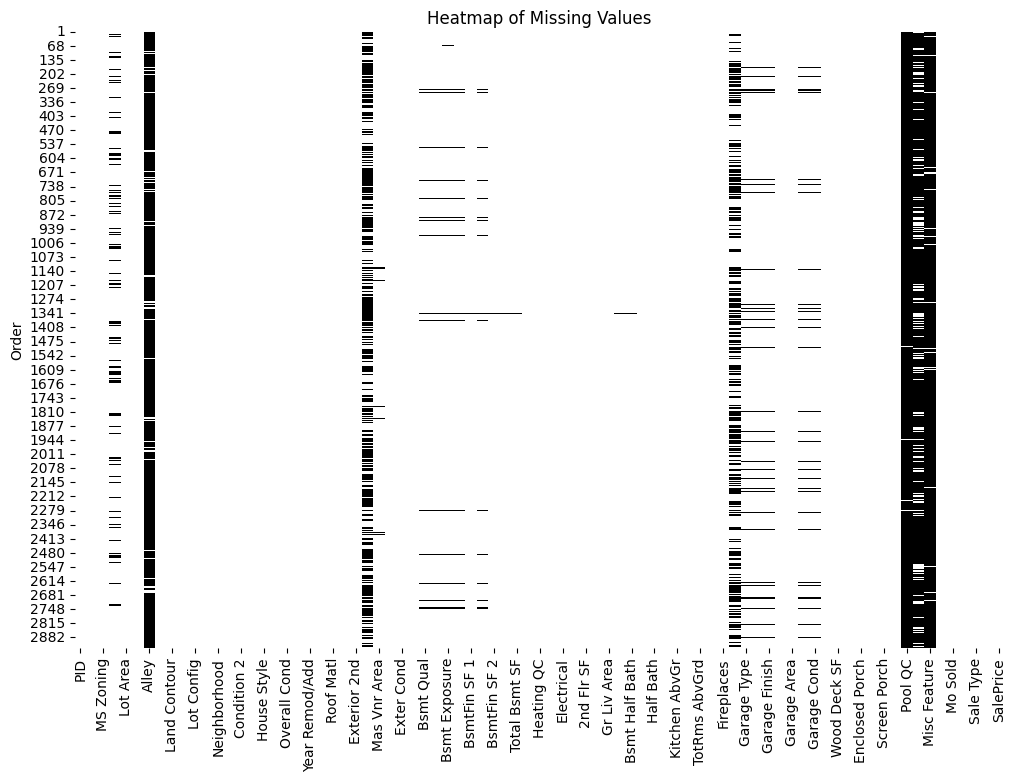

In [ ]:
# Visualize missing values using a heatmap
plt.figure(figsize=(12, 8))
# make black and white cmap
cmap = sns.color_palette("gray_r", as_cmap=True)
sns.heatmap(df.isnull(), cbar=False, cmap=cmap)
plt.title("Heatmap of Missing Values")
plt.show()

In [ ]:
# add sorting

missing_percentage = df.isnull().mean().sort_values(ascending=False)*100

print("\nPercentage of missing values per column:")
print(missing_percentage[missing_percentage > 0])



Percentage of missing values per column:
Pool QC           99.556314
Misc Feature      96.382253
Alley             93.242321
Fence             80.477816
Mas Vnr Type      60.580205
Fireplace Qu      48.532423
Lot Frontage      16.723549
Garage Cond        5.426621
Garage Finish      5.426621
Garage Yr Blt      5.426621
Garage Qual        5.426621
Garage Type        5.358362
Bsmt Exposure      2.832765
BsmtFin Type 2     2.764505
Bsmt Qual          2.730375
Bsmt Cond          2.730375
BsmtFin Type 1     2.730375
Mas Vnr Area       0.784983
Bsmt Half Bath     0.068259
Bsmt Full Bath     0.068259
BsmtFin SF 1       0.034130
Garage Cars        0.034130
Electrical         0.034130
Total Bsmt SF      0.034130
Bsmt Unf SF        0.034130
BsmtFin SF 2       0.034130
Garage Area        0.034130
dtype: float64


NaN in Pool QC should be considered as a category, not NaN

----------

###Missing Values Types: MCAR, MAR, MNAR


1.   Missing Completely at Random (MCAR)
2.   Missing at Randon (MAR)
3.   Missing not at Random (MNAR)



* MCAR means the missingness has no relationship with the observed or unobserved data.

* To illustrate MCAR in the dataset, you can randomly remove values.

T-Test Calculation:

A t-test is used to compare the means of the original and simulated datasets to determine if the observed difference is statistically significant.
The p-value will help assess whether the change due to MNAR is significant at a 5% level.

In [ ]:
# Assuming df_tmp1 is a copy of the original dataframe (df)
df_tmp1 = df.copy()

# Randomly remove 5% of 'Gr Liv Area' values to simulate MCAR
np.random.seed(42)
mcar_mask = np.random.rand(len(df_tmp1)) < 0.05
df_tmp1.loc[mcar_mask, 'Gr Liv Area'] = np.nan

print("\nData with MCAR simulated in 'Gr Liv Area':")
print(df_tmp1['Gr Liv Area'].isnull().sum())

# Concatenate df.describe()['Gr Liv Area'] and df_tmp1.describe()['Gr Liv Area'] in one dataset
df_tmp1_stats = pd.concat([df.describe()['Gr Liv Area'], df_tmp1.describe()['Gr Liv Area']], axis=1)
df_tmp1_stats.columns = ['Original', 'MCAR Simulated']

# Calculate statistical significance for the change of metrics
df_tmp1_stats['Change'] = df_tmp1_stats['MCAR Simulated'] - df_tmp1_stats['Original']
df_tmp1_stats['Change %'] = (df_tmp1_stats['Change'] / df_tmp1_stats['Original']) * 100
df_tmp1_stats['Change %'] = df_tmp1_stats['Change %'].apply(lambda x: round(x, 2))

# Display the statistics comparison
print(df_tmp1_stats)

from scipy.stats import ttest_ind

# Extracting non-null values for 'Gr Liv Area' from both datasets
original_values = df['Gr Liv Area'].dropna()
mcar_simulated_values = df_tmp1['Gr Liv Area'].dropna()

# Perform a t-test to compare the means of the original and MCAR-simulated data
t_stat, p_value = ttest_ind(original_values, mcar_simulated_values, equal_var=False, nan_policy='omit')

# Display the t-statistic and p-value
print("\nStatistical significance of the change in 'Gr Liv Area':")
print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_value:.4e}")

# Interpretation
if p_value < 0.05:
    print("The change is statistically significant at the 5% level.")
else:
    print("The change is not statistically significant at the 5% level.")



Data with MCAR simulated in 'Gr Liv Area':
156
          Original  MCAR Simulated      Change  Change %
count  2930.000000     2774.000000 -156.000000     -5.32
mean   1499.690444     1504.193583    4.503140      0.30
std     505.508887      508.079480    2.570592      0.51
min     334.000000      407.000000   73.000000     21.86
25%    1126.000000     1131.000000    5.000000      0.44
50%    1442.000000     1442.000000    0.000000      0.00
75%    1742.750000     1743.000000    0.250000      0.01
max    5642.000000     5642.000000    0.000000      0.00

Statistical significance of the change in 'Gr Liv Area':
T-statistic: -0.3354
P-value: 7.3734e-01
The change is not statistically significant at the 5% level.


-------

* MAR means the missingness is related to other observed variables but not to the value itself.

* To illustrate MAR, you can remove values based on another feature.

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind

# Assuming df_tmp2 is a copy of the original dataframe (df)
df_tmp2 = df.copy()

# Remove 'Gr Liv Area' values for houses where 'GarageType' = 'Detchd' to simulate MAR
mar_mask = df_tmp2['Garage Type'] == 'Detchd'
df_tmp2.loc[mar_mask, 'Gr Liv Area'] = np.nan

print("\nData with MAR simulated in 'Gr Liv Area':")
print(df_tmp2['Gr Liv Area'].isnull().sum())

# Concatenate df.describe()['Gr Liv Area'] and df_tmp2.describe()['Gr Liv Area'] in one dataset
df_tmp2_stats = pd.concat([df.describe()['Gr Liv Area'], df_tmp2.describe()['Gr Liv Area']], axis=1)
df_tmp2_stats.columns = ['Original', 'MAR Simulated']

# Calculate change in statistics
df_tmp2_stats['Change'] = df_tmp2_stats['MAR Simulated'] - df_tmp2_stats['Original']
df_tmp2_stats['Change %'] = (df_tmp2_stats['Change'] / df_tmp2_stats['Original']) * 100
df_tmp2_stats['Change %'] = df_tmp2_stats['Change %'].apply(lambda x: round(x, 2))

# Display the statistics comparison
print("\nStatistics Comparison (Original vs MAR Simulated for 'Gr Liv Area'):")
print(df_tmp2_stats)

# Calculate statistical significance for the change of metrics
# Extracting non-null values for 'Gr Liv Area' from both datasets
original_values_mar = df['Gr Liv Area'].dropna()
mar_simulated_values = df_tmp2['Gr Liv Area'].dropna()

# Perform a t-test to compare the means of the original and MAR-simulated data
t_stat_mar, p_value_mar = ttest_ind(original_values_mar, mar_simulated_values, equal_var=False, nan_policy='omit')

# Display the t-statistic and p-value
print("\nStatistical significance of the change in 'Gr Liv Area' due to MAR:")
print(f"T-statistic: {t_stat_mar:.4f}")
print(f"P-value: {p_value_mar:.4e}")

# Interpretation
if p_value_mar < 0.05:
    print("The change is statistically significant at the 5% level.")
else:
    print("The change is not statistically significant at the 5% level.")



Data with MAR simulated in 'Gr Liv Area':
782

Statistics Comparison (Original vs MAR Simulated for 'Gr Liv Area'):
          Original  MAR Simulated      Change  Change %
count  2930.000000    2148.000000 -782.000000    -26.69
mean   1499.690444    1574.968343   75.277899      5.02
std     505.508887     510.371332    4.862444      0.96
min     334.000000     334.000000    0.000000      0.00
25%    1126.000000    1216.000000   90.000000      7.99
50%    1442.000000    1509.000000   67.000000      4.65
75%    1742.750000    1818.500000   75.750000      4.35
max    5642.000000    5642.000000    0.000000      0.00

Statistical significance of the change in 'Gr Liv Area' due to MAR:
T-statistic: -5.2136
P-value: 1.9336e-07
The change is statistically significant at the 5% level.


------------

* MNAR means the missingness is related to the value itself, e.g., missing values are more likely for larger houses.

* To illustrate MNAR, you can remove values based on the feature itself.

In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind

# Assuming df_tmp3 is a copy of the original dataframe (df)
df_tmp3 = df.copy()

# Remove 'Gr Liv Area' values where 'Gr Liv Area' is above a certain threshold to simulate MNAR
mnar_mask = df_tmp3['Gr Liv Area'] > 2000
df_tmp3.loc[mnar_mask, 'Gr Liv Area'] = np.nan

print("\nData with MNAR simulated in 'Gr Liv Area':")
print(df_tmp3['Gr Liv Area'].isnull().sum())

# Concatenate df.describe()['Gr Liv Area'] and df_tmp3.describe()['Gr Liv Area'] in one dataset
df_tmp3_stats = pd.concat([df.describe()['Gr Liv Area'], df_tmp3.describe()['Gr Liv Area']], axis=1)
df_tmp3_stats.columns = ['Original', 'MNAR Simulated']

# Calculate change in statistics
df_tmp3_stats['Change'] = df_tmp3_stats['MNAR Simulated'] - df_tmp3_stats['Original']
df_tmp3_stats['Change %'] = (df_tmp3_stats['Change'] / df_tmp3_stats['Original']) * 100
df_tmp3_stats['Change %'] = df_tmp3_stats['Change %'].apply(lambda x: round(x, 2))

# Display the statistics comparison
print("\nStatistics Comparison (Original vs MNAR Simulated for 'Gr Liv Area'):")
print(df_tmp3_stats)

# Calculate statistical significance for the change of metrics
# Extracting non-null values for 'Gr Liv Area' from both datasets
original_values_mnar = df['Gr Liv Area'].dropna()
mnar_simulated_values = df_tmp3['Gr Liv Area'].dropna()

# Perform a t-test to compare the means of the original and MNAR-simulated data
t_stat_mnar, p_value_mnar = ttest_ind(original_values_mnar, mnar_simulated_values, equal_var=False, nan_policy='omit')

# Display the t-statistic and p-value
print("\nStatistical significance of the change in 'Gr Liv Area' due to MNAR:")
print(f"T-statistic: {t_stat_mnar:.4f}")
print(f"P-value: {p_value_mnar:.4e}")

# Interpretation
if p_value_mnar < 0.05:
    print("The change is statistically significant at the 5% level.")
else:
    print("The change is not statistically significant at the 5% level.")



Data with MNAR simulated in 'Gr Liv Area':
402

Statistics Comparison (Original vs MNAR Simulated for 'Gr Liv Area'):
          Original  MNAR Simulated       Change  Change %
count  2930.000000     2528.000000  -402.000000    -13.72
mean   1499.690444     1352.535997  -147.154447     -9.81
std     505.508887      330.391833  -175.117055    -34.64
min     334.000000      334.000000     0.000000      0.00
25%    1126.000000     1087.500000   -38.500000     -3.42
50%    1442.000000     1360.000000   -82.000000     -5.69
75%    1742.750000     1621.000000  -121.750000     -6.99
max    5642.000000     2000.000000 -3642.000000    -64.55

Statistical significance of the change in 'Gr Liv Area' due to MNAR:
T-statistic: 12.8868
P-value: 2.0403e-37
The change is statistically significant at the 5% level.


----------

In [ ]:
# calculate avg sale price with Pool QC and without it
df.groupby('Pool QC', dropna=False)['SalePrice'].mean()

,SalePrice
Pool QC,
Ex,477500.000000
Fa,215500.000000
Gd,216492.500000
TA,170500.000000
NaN,180327.043538


In [ ]:
# Percentage of missing vals
# Pool QC           99.556314
# Misc Feature      96.382253
# Alley             93.242321
# Fence             80.477816
# Mas Vnr Type      60.580205
# Fireplace Qu      48.532423
not_NaN_cols = ['Pool QC', 'Misc Feature', 'Alley', 'Fence', 'Mas Vnr Type', 'Fireplace Qu']

In [ ]:
df[not_NaN_cols] = df[not_NaN_cols].fillna('None')

----------

## Listwise and Pairwise deletion



In [ ]:
import pandas as pd
import numpy as np

# Load the Ames Housing dataset (assuming it's already loaded as df)
df_tmp_listwise = df.copy()

# Perform listwise deletion: Remove rows with any missing values
listwise_deleted_df = df_tmp_listwise.dropna()

# Calculate the percentage of rows removed by listwise deletion
total_rows = len(df_tmp_listwise)
rows_after_listwise = len(listwise_deleted_df)
listwise_removed_pct = ((total_rows - rows_after_listwise) / total_rows) * 100

# Display the result
print(f"Total rows before listwise deletion: {total_rows}")
print(f"Total rows after listwise deletion: {rows_after_listwise}")
print(f"Percentage of rows removed by listwise deletion: {listwise_removed_pct:.2f}%")


Total rows before listwise deletion: 2930
Total rows after listwise deletion: 2218
Percentage of rows removed by listwise deletion: 24.30%


In [ ]:
# Create a copy of the original dataframe to simulate pairwise deletion
df_tmp_pairwise = df.copy()

# Introduce some missing values to illustrate pairwise deletion
np.random.seed(42)
mcar_mask = np.random.rand(len(df_tmp_pairwise)) < 0.05
df_tmp_pairwise.loc[mcar_mask, 'Gr Liv Area'] = np.nan

# Calculate correlation before and after introducing missing values (pairwise deletion)
original_correlation = df[['Gr Liv Area', 'SalePrice']].corr()

# Perform pairwise deletion: Only exclude rows with missing values for 'Gr Liv Area' or 'SalePrice'
pairwise_correlation = df_tmp_pairwise[['Gr Liv Area', 'SalePrice']].corr()

# Calculate the number of complete rows used for the correlation calculation
pairwise_rows = len(df_tmp_pairwise[['Gr Liv Area', 'SalePrice']].dropna())
pairwise_removed_pct = ((total_rows - pairwise_rows) / total_rows) * 100

# Display the result
print(f"Total rows before introducing missing values: {total_rows}")
print(f"Total rows used for pairwise correlation between 'Gr Liv Area' and 'SalePrice': {pairwise_rows}")
print(f"Percentage of rows removed by pairwise deletion: {pairwise_removed_pct:.2f}%")

# Display correlation matrices for illustration
print("\nOriginal Correlation Matrix:")
print(original_correlation)

print("\nPairwise Deletion Correlation Matrix:")
print(pairwise_correlation)


Total rows before introducing missing values: 2930
Total rows used for pairwise correlation between 'Gr Liv Area' and 'SalePrice': 2774
Percentage of rows removed by pairwise deletion: 5.32%

Original Correlation Matrix:
             Gr Liv Area  SalePrice
Gr Liv Area      1.00000    0.70678
SalePrice        0.70678    1.00000

Pairwise Deletion Correlation Matrix:
             Gr Liv Area  SalePrice
Gr Liv Area      1.00000    0.70939
SalePrice        0.70939    1.00000


## Imputing Methods

In [ ]:
# Importing necessary libraries
import pandas as pd
import numpy as np
from scipy.stats import ttest_ind
from sklearn.impute import SimpleImputer

# Selecting specific columns for imputation examples
numeric_column = 'Lot Frontage'
categorical_column = 'Garage Type'

In [ ]:
# Creating copies of the dataframe for different imputation methods
df_mean_impute = df.copy()
df_mode_impute = df.copy()
df_constant_impute = df.copy()

### Mean imputation for the numerical column

In [ ]:
mean_imputer = SimpleImputer(strategy='mean')
df_mean_impute.loc[:, [numeric_column]] = mean_imputer.fit_transform(df_mean_impute[[numeric_column]])

print(f"Mean imputation applied to '{numeric_column}'.")

Mean imputation applied to 'Lot Frontage'.


### Mode imputation for the categorical column

In [ ]:
mode_imputer = SimpleImputer(strategy='most_frequent')
df_mode_impute.loc[:, [categorical_column]] = mode_imputer.fit_transform(df_mode_impute[[categorical_column]])

print(f"Mode imputation applied to '{categorical_column}'.")

Mode imputation applied to 'Garage Type'.


### Constant imputation for numerical and categorical columns

In [ ]:

constant_imputer_num = SimpleImputer(strategy='constant', fill_value=0)
constant_imputer_cat = SimpleImputer(strategy='constant', fill_value='None')

df_constant_impute.loc[:, [numeric_column]] = constant_imputer_num.fit_transform(df_constant_impute[[numeric_column]])
df_constant_impute.loc[:, [categorical_column]] = constant_imputer_cat.fit_transform(df_constant_impute[[categorical_column]])

print(f"Constant imputation applied to '{numeric_column}' and '{categorical_column}'.")

Constant imputation applied to 'Lot Frontage' and 'Garage Type'.


### Calculate descriptive statistics before and after imputation for numerical column

In [ ]:
original_stats = df[[numeric_column]].describe()
mean_impute_stats = df_mean_impute[[numeric_column]].describe()
constant_impute_stats = df_constant_impute[[numeric_column]].describe()

# Concatenate statistics for comparison
stats_comparison = pd.concat([original_stats, mean_impute_stats, constant_impute_stats],
                             axis=1, keys=['Original', 'Mean Imputed', 'Constant Imputed'])
print(f"\nDescriptive Statistics for Numerical Column {numeric_column}:")
print(stats_comparison)


Descriptive Statistics for Numerical Column Lot Frontage:
          Original Mean Imputed Constant Imputed
      Lot Frontage Lot Frontage     Lot Frontage
count  2440.000000  2930.000000      2930.000000
mean     69.224590    69.224590        57.647782
std      23.365335    21.321523        33.499441
min      21.000000    21.000000         0.000000
25%      58.000000    60.000000        43.000000
50%      68.000000    69.224590        63.000000
75%      80.000000    78.000000        78.000000
max     313.000000   313.000000       313.000000


In [ ]:
# Function to calculate and print the statistical significance of change in means
def print_statistical_significance(imputation_method, original_values, imputed_values):
    t_stat, p_value = ttest_ind(original_values, imputed_values, nan_policy='omit')
    print(f"{numeric_column} - {imputation_method} Imputation - P-value: {p_value:.4e}")
    if p_value < 0.05:
        print(f"Explanation: A very low p-value (< 0.05) indicates that {imputation_method} imputation has significantly altered the distribution compared to the original data.")
    else:
        print(f"Explanation: A high p-value (> 0.05) suggests that {imputation_method} imputation did not significantly change the distribution compared to the original data.")

# Mean imputation statistical significance
print("\nStatistical Significance for Mean Imputation (Numerical Column):")
original_values = df[numeric_column].dropna()
imputed_values = df_mean_impute[numeric_column]
print_statistical_significance("Mean", original_values, imputed_values)

# Constant imputation statistical significance
print("\nStatistical Significance for Constant Imputation (Numerical Column):")
imputed_values = df_constant_impute[numeric_column]
print_statistical_significance("Constant", original_values, imputed_values)



Statistical Significance for Mean Imputation (Numerical Column):
Lot Frontage - Mean Imputation - P-value: 1.0000e+00
Explanation: A high p-value (> 0.05) suggests that Mean imputation did not significantly change the distribution compared to the original data.

Statistical Significance for Constant Imputation (Numerical Column):
Lot Frontage - Constant Imputation - P-value: 3.6752e-46
Explanation: A very low p-value (< 0.05) indicates that Constant imputation has significantly altered the distribution compared to the original data.


In [ ]:
# Display original and mode-imputed values for categorical column (first 10 rows)
original_cat_values = df[categorical_column].head(10)
imputed_cat_values = df_mode_impute[categorical_column].head(10)
comparison_cat = pd.DataFrame({'Original': original_cat_values, 'Mode Imputed': imputed_cat_values})

print("\nOriginal and Mode Imputed Values for Categorical Column (First 10 Rows):")
print(comparison_cat)

# Calculate mode and frequency for original and mode-imputed categorical values
original_mode = df[categorical_column].mode()[0]
original_frequency = df[categorical_column].value_counts().max()
mode_imputed_mode = df_mode_impute[categorical_column].mode()[0]
mode_imputed_frequency = df_mode_impute[categorical_column].value_counts().max()

print("\nMode and Frequency for Categorical Column (Garage Type):")
print(f"Original Mode: {original_mode}, Frequency: {original_frequency}")
print(f"Mode Imputed Mode: {mode_imputed_mode}, Frequency: {mode_imputed_frequency}")


Original and Mode Imputed Values for Categorical Column (First 10 Rows):
      Original Mode Imputed
Order                      
1       Attchd       Attchd
2       Attchd       Attchd
3       Attchd       Attchd
4       Attchd       Attchd
5       Attchd       Attchd
6       Attchd       Attchd
7       Attchd       Attchd
8       Attchd       Attchd
9       Attchd       Attchd
10      Attchd       Attchd

Mode and Frequency for Categorical Column (Garage Type):
Original Mode: Attchd, Frequency: 1731
Mode Imputed Mode: Attchd, Frequency: 1888


### Advanced Imputation
Explanation: Model-based imputation uses predictive models to estimate missing values based on other available features.

Linear Regression imputation uses a linear model to predict missing values, while KNN imputation fills missing values based on the nearest neighbors, retaining relationships between features.

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, BayesianRidge
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import KNNImputer, IterativeImputer, SimpleImputer
from sklearn.experimental import enable_iterative_imputer  # noqa
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from scipy.stats import ttest_ind, chi2_contingency
import matplotlib.pyplot as plt
import seaborn as sns

# For better visualization in Colab
%matplotlib inline

# Load dataset (Assuming 'df' is already loaded; uncomment to load your dataset)
# df = pd.read_csv('Ames_Housing.csv')

# Selecting specific columns for imputation examples
numeric_column = 'Lot Frontage'
categorical_column = 'Garage Type'
predictor_columns = ['Lot Area', 'Overall Qual', 'Year Built', 'Gr Liv Area']

# Ensuring the selected columns are present in the dataset
required_columns = [numeric_column, categorical_column] + predictor_columns
missing_columns = [col for col in required_columns if col not in df.columns]
if missing_columns:
    raise ValueError(f"Columns '{', '.join(missing_columns)}' not found in the dataset.")

# Display initial missing value counts
print("Initial Missing Values:")
print(df[required_columns].isna().sum())

Initial Missing Values:
Lot Frontage    490
Garage Type     157
Lot Area          0
Overall Qual      0
Year Built        0
Gr Liv Area       0
dtype: int64


### Linear Regression Imputation for Numerical Values
is a method in which we estimate the missing values by Regression using other variables as the parameters.

In [ ]:
# Create a copy of the DataFrame for Linear Regression imputation
df_linear_impute = df.copy()

# Split data into training and testing sets for Linear Regression imputation
train_data = df_linear_impute[df_linear_impute[numeric_column].notna()]
test_data = df_linear_impute[df_linear_impute[numeric_column].isna()]

# Separate predictors and target
X_train = train_data[predictor_columns]
y_train = train_data[numeric_column]
X_test = test_data[predictor_columns]

# Check if there are missing values in predictors
if X_train.isna().sum().sum() > 0 or X_test.isna().sum().sum() > 0:
    print("Predictor columns contain missing values. Please handle them before Linear Regression Imputation.")
else:
    # Train Linear Regression model and predict missing values
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    predicted_values = lr_model.predict(X_test)

    # Fill missing values with predicted values
    df_linear_impute.loc[df_linear_impute[numeric_column].isna(), numeric_column] = predicted_values
    print(f"\nLinear Regression imputation applied to '{numeric_column}'.")



Linear Regression imputation applied to 'Lot Frontage'.


### Nearest neighbors imputation
The KNNImputer class provides imputation for filling in missing values using the k-Nearest Neighbors approach. By default, a euclidean distance metric that supports missing values, nan_euclidean_distances, is used to find the nearest neighbors. Each missing feature is imputed using values from n_neighbors nearest neighbors that have a value for the feature. The feature of the neighbors are averaged uniformly or weighted by distance to each neighbor. If a sample has more than one feature missing, then the neighbors for that sample can be different depending on the particular feature being imputed. When the number of available neighbors is less than n_neighbors and there are no defined distances to the training set, the training set average for that feature is used during imputation. If there is at least one neighbor with a defined distance, the weighted or unweighted average of the remaining neighbors will be used during imputation. If a feature is always missing in training, it is removed during transform. For more information on the methodology, see ref. [OL2001].

https://scikit-learn.org/1.5/modules/impute.html#nearest-neighbors-imputation


In [ ]:
# Create a copy of the DataFrame for KNN imputation
df_knn_impute = df.copy()

# Initialize KNNImputer for numerical columns
knn_imputer_num = KNNImputer(n_neighbors=5)

# Impute numerical columns
df_knn_impute[[numeric_column] + predictor_columns] = knn_imputer_num.fit_transform(df_knn_impute[[numeric_column] + predictor_columns])

print(f"\nKNN imputation applied to numerical columns: '{numeric_column}' and {predictor_columns}.")



KNN imputation applied to numerical columns: 'Lot Frontage' and ['Lot Area', 'Overall Qual', 'Year Built', 'Gr Liv Area'].


### Iterative Imputer
A more sophisticated approach is to use the IterativeImputer class, which models each feature with missing values as a function of other features, and uses that estimate for imputation. It does so in an iterated round-robin fashion: at each step, a feature column is designated as output y and the other feature columns are treated as inputs X. A regressor is fit on (X, y) for known y. Then, the regressor is used to predict the missing values of y. This is done for each feature in an iterative fashion, and then is repeated for max_iter imputation rounds. The results of the final imputation round are returned.
https://scikit-learn.org/1.5/modules/impute.html#multivariate-feature-imputation

In [ ]:
# Create a copy of the DataFrame for Iterative Imputer
df_iterative_impute = df.copy()

# Initialize IterativeImputer for numerical columns using Bayesian Ridge estimator
iterative_imputer_num = IterativeImputer(estimator=BayesianRidge(), random_state=42)

# Impute numerical columns
df_iterative_impute[[numeric_column] + predictor_columns] = iterative_imputer_num.fit_transform(df_iterative_impute[[numeric_column] + predictor_columns])

print(f"\nIterative Imputer applied to numerical columns: '{numeric_column}' and {predictor_columns}.")



Iterative Imputer applied to numerical columns: 'Lot Frontage' and ['Lot Area', 'Overall Qual', 'Year Built', 'Gr Liv Area'].


### Simple Imputer for Categorical Values (Alternative Method)

In [ ]:
# Create a copy of the DataFrame for categorical imputation using SimpleImputer
df_simple_cat_impute = df.copy()

# Replace known missing representations with np.nan
df_simple_cat_impute[categorical_column] = df_simple_cat_impute[categorical_column].replace(['nan', 'None', ''], np.nan)

# Initialize SimpleImputer with 'most_frequent' strategy
simple_imputer_cat = SimpleImputer(strategy='most_frequent')

# Impute missing categorical values
# Flatten the array returned by fit_transform using `.ravel()`
df_simple_cat_impute[categorical_column] = simple_imputer_cat.fit_transform(df_simple_cat_impute[[categorical_column]]).ravel()

print(f"\nSimple Imputer applied to categorical column '{categorical_column}'.")


Simple Imputer applied to categorical column 'Garage Type'.


### Descriptive Statistics for Numerical Imputations

In [ ]:
# Calculate descriptive statistics before and after imputation for numerical column
original_stats = df[[numeric_column]].describe()
linear_impute_stats = df_linear_impute[[numeric_column]].describe()
knn_impute_stats = df_knn_impute[[numeric_column]].describe()
iterative_impute_stats = df_iterative_impute[[numeric_column]].describe()

# Concatenate statistics for comparison
stats_comparison = pd.concat(
    [original_stats, linear_impute_stats, knn_impute_stats, iterative_impute_stats],
    axis=1,
    keys=['Original', 'Linear Regression Imputed', 'KNN Imputed', 'Iterative Imputed']
)

print("\nDescriptive Statistics for Numerical Column (Lot Frontage):")
print(stats_comparison)



Descriptive Statistics for Numerical Column (Lot Frontage):
          Original Linear Regression Imputed  KNN Imputed Iterative Imputed
      Lot Frontage              Lot Frontage Lot Frontage      Lot Frontage
count  2440.000000               2930.000000  2930.000000       2930.000000
mean     69.224590                 70.028494    70.105666         70.003991
std      23.365335                 22.970939    22.816034         22.973517
min      21.000000                 21.000000    21.000000         21.000000
25%      58.000000                 60.000000    60.000000         60.000000
50%      68.000000                 69.000000    70.000000         69.000000
75%      80.000000                 80.000000    80.150000         80.000000
max     313.000000                313.000000   313.000000        313.000000


### Statistical Significance Tests for Numerical Imputations

In [ ]:
# Function to calculate and print the statistical significance of change in means
def print_statistical_significance(imputation_method, original_values, imputed_values):
    t_stat, p_value = ttest_ind(original_values, imputed_values, nan_policy='omit')
    print(f"{numeric_column} - {imputation_method} Imputation - P-value: {p_value:.4e}")
    if p_value < 0.05:
        print(f"Explanation: A very low p-value (< 0.05) indicates that {imputation_method} imputation has significantly altered the distribution compared to the original data.\n")
    else:
        print(f"Explanation: A high p-value (> 0.05) suggests that {imputation_method} imputation did not significantly change the distribution compared to the original data.\n")

# Statistical significance for each imputation method
print("Statistical Significance for Linear Regression Imputation (Numerical Column):")
print_statistical_significance("Linear Regression", df[numeric_column].dropna(), df_linear_impute[numeric_column])

print("Statistical Significance for KNN Imputation (Numerical Column):")
print_statistical_significance("KNN", df[numeric_column].dropna(), df_knn_impute[numeric_column])

print("Statistical Significance for Iterative Imputation (Numerical Column):")
print_statistical_significance("Iterative", df[numeric_column].dropna(), df_iterative_impute[numeric_column])


Statistical Significance for Linear Regression Imputation (Numerical Column):
Lot Frontage - Linear Regression Imputation - P-value: 2.0521e-01
Explanation: A high p-value (> 0.05) suggests that Linear Regression imputation did not significantly change the distribution compared to the original data.

Statistical Significance for KNN Imputation (Numerical Column):
Lot Frontage - KNN Imputation - P-value: 1.6348e-01
Explanation: A high p-value (> 0.05) suggests that KNN imputation did not significantly change the distribution compared to the original data.

Statistical Significance for Iterative Imputation (Numerical Column):
Lot Frontage - Iterative Imputation - P-value: 2.1939e-01
Explanation: A high p-value (> 0.05) suggests that Iterative imputation did not significantly change the distribution compared to the original data.



### Frequency Distribution for Categorical Imputations

In [ ]:
# Function to calculate and print the statistical significance of change in categorical distributions
def print_chi_square_significance(original_values, imputed_values, column_name):
    # Replace known missing representations with np.nan and drop missing values
    original_values_clean = original_values.replace(['nan', 'None', 'missing'], np.nan).dropna()
    imputed_values_clean = imputed_values.replace(['nan', 'None', 'missing'], np.nan).dropna()

    # Get all unique categories from both original and imputed values
    all_categories = pd.Index(original_values_clean.unique()).union(imputed_values_clean.unique())

    # Create contingency table by reindexing value counts to ensure all categories are represented
    original_counts = original_values_clean.value_counts().reindex(all_categories, fill_value=0)
    imputed_counts = imputed_values_clean.value_counts().reindex(all_categories, fill_value=0)

    # Construct the contingency table with counts of each category
    contingency_table = pd.DataFrame({'Original': original_counts, 'Imputed': imputed_counts})

    # Ensure there are no empty columns (as chi2_contingency cannot work with zero columns)
    if (contingency_table.sum(axis=0) == 0).any():
        print(f"\nChi-square Test for {column_name} could not be performed due to insufficient data.")
        return

    # Print the contingency table for reference
    print(f"\nContingency Table for {column_name}:")
    print(contingency_table)

    # Perform chi-square test
    chi2, p_value, _, _ = chi2_contingency(contingency_table)
    print(f"\nChi-square Test for {column_name} - P-value: {p_value:.4e}")
    if p_value < 0.05:
        print(f"Explanation: A very low p-value (< 0.05) indicates that the imputation has significantly altered the distribution of the categorical values compared to the original data.\n")
    else:
        print(f"Explanation: A high p-value (> 0.05) suggests that the imputation did not significantly change the distribution of the categorical values compared to the original data.\n")

# Chi-square test for KNN Imputation (Categorical Column)
print("Chi-square Test for Most Frequent Imputation (Categorical Column):")
print_chi_square_significance(df[categorical_column], df_simple_cat_impute[categorical_column], categorical_column)

# Chi-square test for Simple Imputer (Categorical Column)
print("Chi-square Test for Simple Imputer (Categorical Column):")
print_chi_square_significance(df[categorical_column], df_simple_cat_impute[categorical_column], categorical_column)


Chi-square Test for Most Frequent Imputation (Categorical Column):

Contingency Table for Garage Type:
         Original  Imputed
Attchd       1731     1888
BuiltIn       186      186
Basment        36       36
Detchd        782      782
CarPort        15       15
2Types         23       23

Chi-square Test for Garage Type - P-value: 7.7788e-01
Explanation: A high p-value (> 0.05) suggests that the imputation did not significantly change the distribution of the categorical values compared to the original data.

Chi-square Test for Simple Imputer (Categorical Column):

Contingency Table for Garage Type:
         Original  Imputed
Attchd       1731     1888
BuiltIn       186      186
Basment        36       36
Detchd        782      782
CarPort        15       15
2Types         23       23

Chi-square Test for Garage Type - P-value: 7.7788e-01
Explanation: A high p-value (> 0.05) suggests that the imputation did not significantly change the distribution of the categorical values compared

### Visualization of Imputation Effects

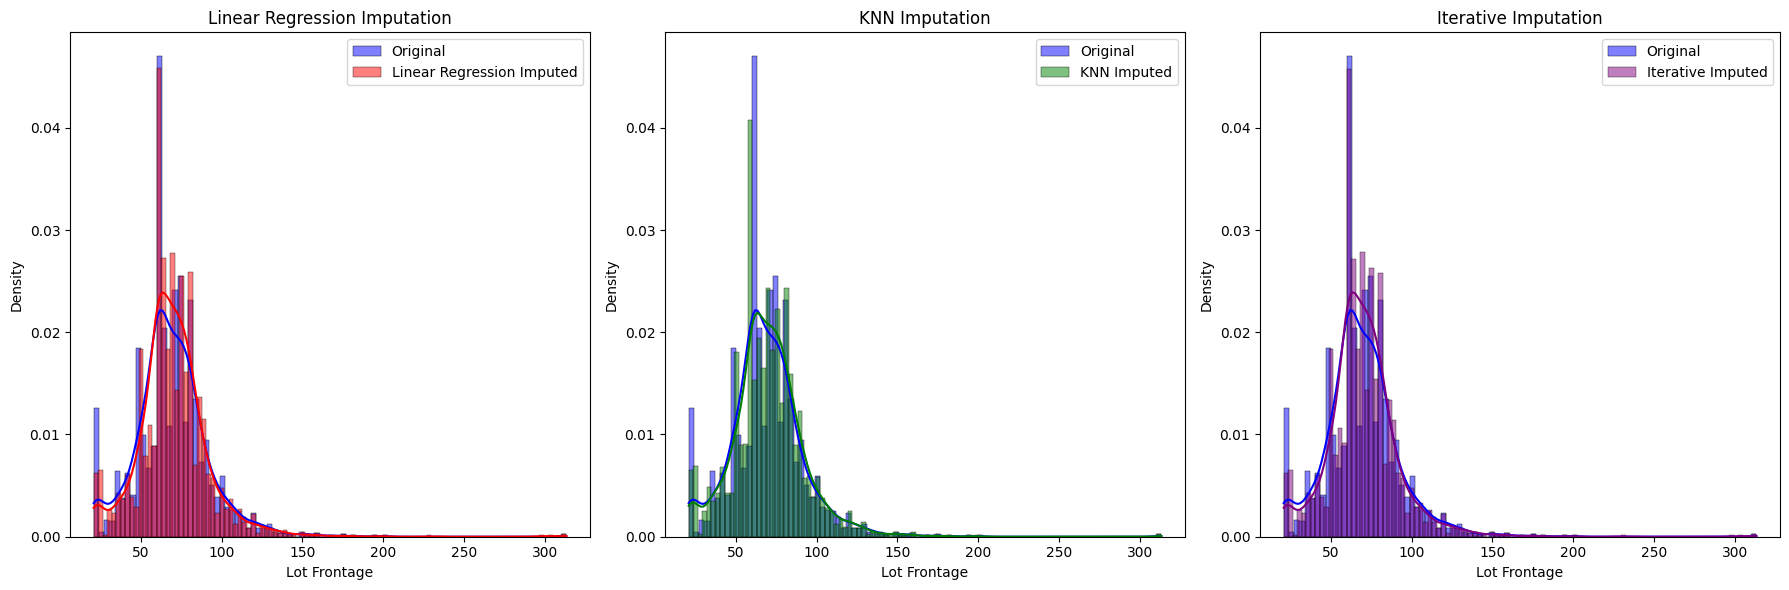

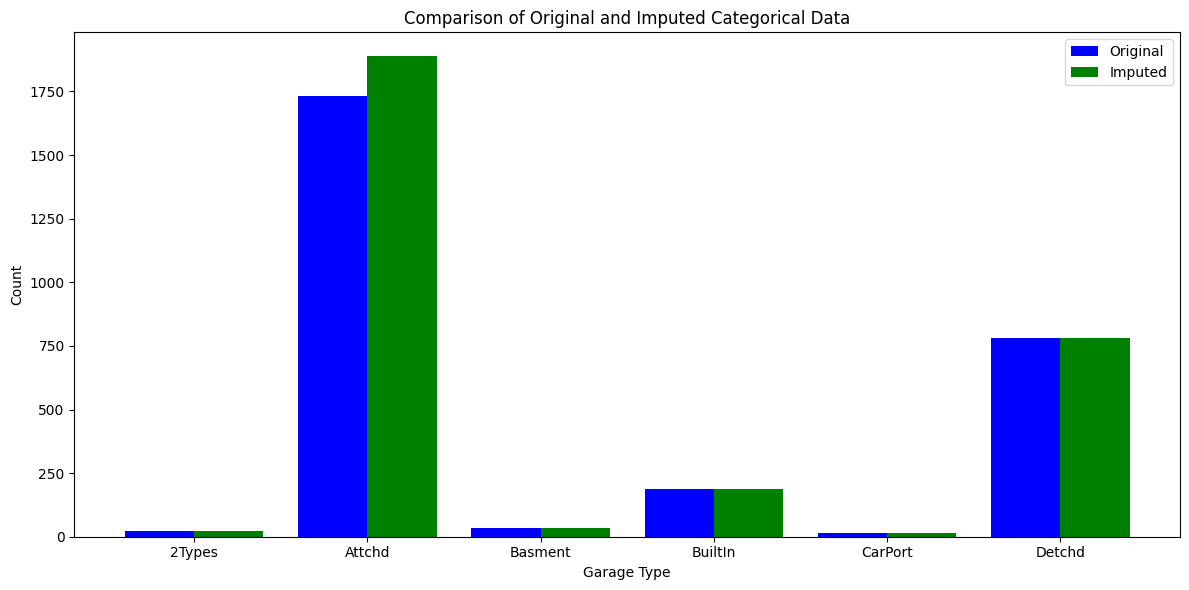

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Visualization of Numerical Imputation
plt.figure(figsize=(18, 6))

# Original vs Linear Regression Imputed
plt.subplot(1, 3, 1)
sns.histplot(df[numeric_column].dropna(), color='blue', label='Original', kde=True, stat="density")
sns.histplot(df_linear_impute[numeric_column], color='red', label='Linear Regression Imputed', kde=True, stat="density", alpha=0.5)
plt.title('Linear Regression Imputation')
plt.legend()

# Original vs KNN Imputed
plt.subplot(1, 3, 2)
sns.histplot(df[numeric_column].dropna(), color='blue', label='Original', kde=True, stat="density")
sns.histplot(df_knn_impute[numeric_column], color='green', label='KNN Imputed', kde=True, stat="density", alpha=0.5)
plt.title('KNN Imputation')
plt.legend()

# Original vs Iterative Imputed
plt.subplot(1, 3, 3)
sns.histplot(df[numeric_column].dropna(), color='blue', label='Original', kde=True, stat="density")
sns.histplot(df_iterative_impute[numeric_column], color='purple', label='Iterative Imputed', kde=True, stat="density", alpha=0.5)
plt.title('Iterative Imputation')
plt.legend()

plt.tight_layout()
plt.show()

# Combined Visualization of Categorical Imputation
plt.figure(figsize=(12, 6))

# Get value counts for original and imputed categorical data
original_counts = df[categorical_column].value_counts().reset_index()
imputed_counts = df_simple_cat_impute[categorical_column].value_counts().reset_index()

original_counts.columns = ['Category', 'Original Count']
imputed_counts.columns = ['Category', 'Imputed Count']

# Merge the original and imputed counts for easy plotting
combined_counts = pd.merge(original_counts, imputed_counts, on='Category', how='outer').fillna(0)

# Plotting the combined categorical data side by side
width = 0.4
x = range(len(combined_counts))

plt.bar(x, combined_counts['Original Count'], width=width, color='blue', label='Original', align='center')
plt.bar([p + width for p in x], combined_counts['Imputed Count'], width=width, color='green', label='Imputed', align='center')

# Set labels, title, and legend for the combined categorical plot
plt.xlabel('Garage Type')
plt.ylabel('Count')
plt.xticks([p + width / 2 for p in x], combined_counts['Category'])
plt.title('Comparison of Original and Imputed Categorical Data')
plt.legend()

plt.tight_layout()
plt.show()


### Summary and Interpretation

In [ ]:
# Summary of Imputation Methods and Their Impact

print("\nSummary of Imputation Methods and Their Statistical Impact:")

# Numerical Imputation
print("\nNumerical Imputation:")
print(f"- Linear Regression Imputation P-value: {ttest_ind(df[numeric_column].dropna(), df_linear_impute[numeric_column], nan_policy='omit')[1]:.4e}")
print(f"- KNN Imputation P-value: {ttest_ind(df[numeric_column].dropna(), df_knn_impute[numeric_column], nan_policy='omit')[1]:.4e}")
print(f"- Iterative Imputation P-value: {ttest_ind(df[numeric_column].dropna(), df_iterative_impute[numeric_column], nan_policy='omit')[1]:.4e}")

# Categorical Imputation
print("\nCategorical Imputation:")
print(f"- Simple Imputer Chi-square P-value: {chi2_contingency(pd.crosstab(df[categorical_column], df_simple_cat_impute[categorical_column]))[1]:.4e}")

# Interpretation
print("\nInterpretation:")
print("- For numerical imputations, high p-values indicate that imputation methods did not significantly alter the distribution of 'Lot Frontage'.")
print("- For categorical imputations, high p-values suggest that the distribution of 'Garage Type' remains consistent post-imputation.")
print("- Low p-values would indicate significant changes in distributions, implying that the imputation method has altered the data.")



Summary of Imputation Methods and Their Statistical Impact:

Numerical Imputation:
- Linear Regression Imputation P-value: 2.0521e-01
- KNN Imputation P-value: 1.6348e-01
- Iterative Imputation P-value: 2.1939e-01

Categorical Imputation:
- Simple Imputer Chi-square P-value: 0.0000e+00

Interpretation:
- For numerical imputations, high p-values indicate that imputation methods did not significantly alter the distribution of 'Lot Frontage'.
- For categorical imputations, high p-values suggest that the distribution of 'Garage Type' remains consistent post-imputation.
- Low p-values would indicate significant changes in distributions, implying that the imputation method has altered the data.
